In [26]:
import jax.numpy as jnp
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from mpl_toolkits.axes_grid1 import make_axes_locatable
from dataclasses import dataclass
import jaxtyping

# we want to use 64 bit floating precision
import jax
from jax import random, vmap

jax.config.update("jax_enable_x64", True)

sns.set_style("darkgrid")

In [27]:

@dataclass(slots=True)
class StatefulRNGKey:
    key: jaxtyping.Key

    def __init__(self, key: jaxtyping.Key | int):
        if isinstance(key, int):
            key = jax.random.PRNGKey(key)

        self.key = key

    def shaped(self, shape: tuple[int, ...]):
        num_new_keys = jnp.prod(jnp.array(shape)) + 1
        new_keys = jax.random.split(self.key, num=num_new_keys)

        self.key = new_keys[0]
        return new_keys[1:].reshape((*shape, *new_keys.shape[1:]))

    def __call__(self, n: int | None = None):
        if n is None:
            self.key, subkey = jax.random.split(self.key)
            return subkey

        new_keys = jax.random.split(self.key, num=n + 1)
        self.key = new_keys[0]
        return new_keys[1:]


In [28]:
OUTPUT_DIR = (Path().resolve() / "..").resolve() / "report" / "output"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

A4_WIDTH_IN = 8.27

EXPORT_KWARGS = {
    "dpi": 600,
    "bbox_inches": "tight",
}


def add_colorbar(im, fig, ax):
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    fig.colorbar(im, cax=cax, orientation="vertical")


def generate_samples(key, m, K, num_samples, jitter=0):
    """returns M samples from an Gaussian process with mean m and kernel matrix K. The function generates num_samples of z ~ N(0, I) and transforms them into f  ~ N(m, K) via the Cholesky factorization.


    arguments:
        key              -- jax random key for controlling the random number generator
        m                -- mean vector (shape (N,))
        K                -- kernel matrix (shape NxN)
        num_samples      -- number of samples to generate (positive integer)
        jitter           -- amount of jitter (non-negative scalar)

    returns
        f_samples        -- a numpy matrix containing the samples of f (shape N x num_samples)
    """

    # generate samples from N(0, 1) of shape (N, num_samples)
    zs = random.normal(key, shape=(len(K), num_samples))

    ##############################################
    # Your solution goes here
    ##############################################

    N = len(K)
    L = jnp.linalg.cholesky(K + jitter * jnp.identity(N))
    f_samples = m[:, None] + jnp.dot(L, zs)

    ##############################################
    # End of solution
    ##############################################

    # sanity check of dimensions
    assert f_samples.shape == (len(K), num_samples), (
        f"The shape of f_samples appears wrong. Expected shape ({len(K)}, {num_samples}), but the actual shape was {f_samples.shape}. Please check your code. "
    )
    return f_samples


In [29]:
skey = StatefulRNGKey(0)

x_data = jnp.asarray([9.589, 7.375, 4.647, 2.501, 2.538, 6.783, 4.294, 5.111, 0.130, 0.783])
y_data = jnp.asarray([3.032, 3.349, 2.906, 2.126, 1.538, 2.787, 3.078, 2.993, 0.828, -0.331])

beta = 4.0
tau = 2.0



In [30]:
N_w = 2
def prior(key, tau):
    mean = jnp.zeros(N_w)
    cov = tau**2 * jnp.eye(N_w)
    return random.multivariate_normal(key, mean, cov)

def sigmoid(x):
    return 1 / (1 + jnp.exp(-x))

def f(x, w):
    return w[1] * sigmoid(x + w[0])

In [31]:
key = random.PRNGKey(0)

S = 100
N_plot = 1000
x = jnp.linspace(0, 10, N_plot)

prior_realisations = vmap(prior, in_axes=(0, None))(skey.shaped((S,)), tau)
f_x_realisations = vmap(f, in_axes=(None, 0))(x, prior_realisations)



In [47]:
f_x_realisations.shape

(100, 1000)

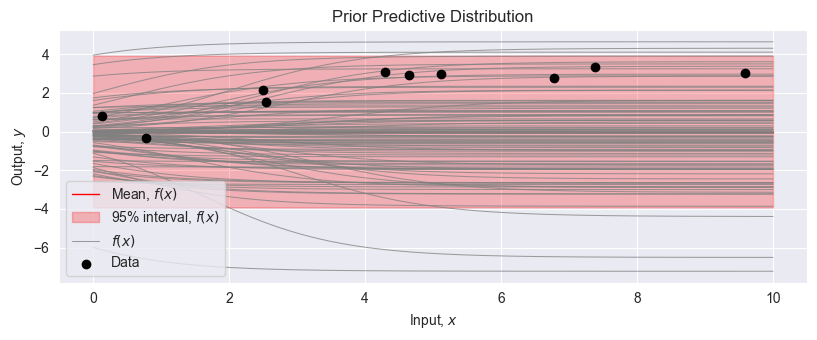

In [ ]:
fig, ax = plt.subplots(figsize=(A4_WIDTH_IN, 3.5))


mean_f_x = jnp.zeros_like(x)
p95_f_x = 1.96 * tau * jnp.ones_like(x)

plt.plot(x, jnp.zeros_like(x), c="red", lw=1, label="Mean, $f(x)$")
plt.fill_between(x, mean_f_x - p95_f_x, mean_f_x + p95_f_x, color="red", alpha=0.25, label="95% interval, $f(x)$")

lines = plt.plot(x, f_x_realisations.T, alpha=0.75, c="gray", lw=0.75)
lines[0].set_label("$f(x)$")
plt.scatter(x_data, y_data, label="Data", c="k", zorder=3)

plt.xlabel("Input, $x$")
plt.ylabel("Output, $y$")
plt.legend()
plt.title("Prior Predictive Distribution")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "2_1.png", **EXPORT_KWARGS)